# v3 dataset showcase

What the v3 routing dataset holds right now: how big it is, what a row looks
like in every flavor it comes in, how it differs from v2, and what corruption
does to a query. Every number on this page is computed live from the
artifacts — re-run top to bottom after any crank. The composition report
(`src/data/v3/report.md`) is the ledger view; this notebook is the
look-at-the-rows view.

In [2]:
import pandas as pd
pd.set_option("display.max_colwidth", 110)

from composition.pool_v3 import LabelledPool
from composition.recipe import Recipe
from augmentation.pool import GeneratedPool

pool = LabelledPool(Recipe.v3()).frame()          # every labelled query, classified
native = pool[pool["native"]]                      # v3's own supply
dataset = pd.read_parquet("../src/data/v3/dataset_v3.parquet")
generated_pool = GeneratedPool().load()            # minted rows (labelled or not)
len(pool), len(native), len(dataset)

/Users/andrei/projects/hybrid-search-rrf-dataset/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(224910, 178768, 36711)

## 1. General statistics

`native` is what the v3 pipeline acquired itself (real queries it labelled +
generated queries that earned labels). The v2-era rows stay in the pool as
measurement material but never enter the dataset.

In [3]:
ids = native["query_id"].astype(str)
origin = pd.Series("natural (real user query)", index=native.index)
origin[ids.str.startswith("lane-")] = "generated: doc-grounded lane mint"
origin[ids.str.startswith("aug-")] = "generated: operator rewrite (corrupt/inject/...)"
origin[ids.str.startswith("syn-")] = "generated: synthetic (query + written answers)"
summary = pd.DataFrame({
    "rows": origin.value_counts(),
    "share": origin.value_counts(normalize=True).round(3),
})
print(f"v3-native labelled pool : {len(native):,}")
print(f"dataset_v3 (the shelf)  : {len(dataset):,} rows, "
      f"{int(dataset['certified'].sum()):,} certified")
print(f"certified split         : "
      f"{dataset[dataset['certified']]['route_class'].value_counts().to_dict()}")
summary

v3-native labelled pool : 178,768
dataset_v3 (the shelf)  : 36,711 rows, 11,167 certified
certified split         : {'dense': 5025, 'sparse': 5025, 'hybrid': 1117}


,rows,share
generated: doc-grounded lane mint,99889,0.559
natural (real user query),71966,0.403
generated: operator rewrite (corrupt/inject/...),6716,0.038
generated: synthetic (query + written answers),197,0.001


## 2. Samples — one of each flavor

- **natural**: harvested from a real dataset's real queries.
- **generated (lane mint)**: written by the LLM to be answered by one real
  corpus document; its label was still earned by retrieval.
- **all_tied**: every route scored the same — usually a one-judged-answer
  artifact, the tail judge's future food.
- **answer-separating** (margin ≥ 0.4): the winning route FOUND an answer the
  runner-up missed entirely.
- **rank-preference** (0.1 ≤ margin < 0.4): both found it; the winner ranks it
  higher — certified since the 2026-08-21 margin decision.

In [4]:
SHOW = ["dataset", "query", "route_class_any", "kind", "margin"]
def sample(frame, n=4, seed=7):
    return frame.sample(min(n, len(frame)), random_state=seed)[SHOW]

print("— natural —")
display(sample(native[~ids.str.startswith(("lane-", "aug-", "syn-"))]))
print("— generated: lane mints —")
display(sample(native[ids.str.startswith("lane-")]))
print("— all_tied —")
display(sample(native[native["kind"].isin(["fake_tie", "genuine_tie"])]))
print("— answer-separating (margin ≥ 0.4) —")
display(sample(native[(native["kind"] == "decisive") & (native["margin"] >= 0.4)]))
print("— rank-preference (0.1 ≤ margin < 0.4) —")
display(sample(native[(native["kind"] == "decisive")
                      & (native["margin"] >= 0.1) & (native["margin"] < 0.4)]))

— natural —


,dataset,query,route_class_any,kind,margin
65374,scirgen-geo-en,What challenges are associated with quantifying Antarctic sea ice variability using satellite data?,dense,undecisive,0.000000
82378,scirgen-geo-en,What does 'soil freezing depth observation' mean in the context of environmental data collection?,,all_zero,0.000000
49068,rarb-math,Problem: A tree is now 12 feet tall and grows 18 inches a year. In how many years will the tree be 36 feet...,dense,decisive,0.810721
87192,scirgen-geo-en,Why might data assimilation and validation be crucial in advancing predictive understanding in alpine hydr...,,all_zero,0.000000


— generated: lane mints —


,dataset,query,route_class_any,kind,margin
212850,crumb-clinical-trial,laparoscopic versus open appendectomy outcomes,dense,decisive,0.810721
118980,bright-biology,how does fluoride prevent tooth decay and strengthen teeth,dense,undecisive,0.020797
140802,clerc,what happens when a child has an interest in a case and is not joined as a party,sparse,decisive,0.810721
197994,quest,Primula species native to Alps,hybrid,undecisive,0.000000


— all_tied —


,dataset,query,route_class_any,kind,margin
187447,quest,2008 Malayalam film about playwright writer village girl,,fake_tie,0.0
112516,scirgen-geo-en,What data collection methods and technological tools enable the synchronization of airborne LiDAR and Envi...,,fake_tie,0.0
46781,rarb-math,"Problem: The polar coordinates of points $A,$ $B,$ and $C$ are $(2,70^\circ),$ $(2 \sqrt{3}, 40^\circ),$ a...",,fake_tie,0.0
139070,freshstack-yolo,how to create a masked tensor in pytorch,,fake_tie,0.0


— answer-separating (margin ≥ 0.4) —


,dataset,query,route_class_any,kind,margin
63507,scirgen-geo-en,Could you provide an example of a dataset used in multi-temporal and multi-angular retrieval approaches fo...,sparse,decisive,0.810721
182854,quest,drama film about ballet dancer and violinist in New York City,sparse,decisive,0.810721
137325,freshstack-yolo,pytorch lstm model factory creators,hybrid,decisive,0.810721
206495,quest,Salvia species endemic to Turkey mountains,sparse,decisive,0.810721


— rank-preference (0.1 ≤ margin < 0.4) —


,dataset,query,route_class_any,kind,margin
221856,rarb-math,"Problem: There is a polynomial $P$ such that for every real number $x$,\n\[\n x^{512} + x^{256} + 1 = (x^...",sparse,decisive,0.106862
91421,scirgen-geo-en,"What are the potential consequences of using satellite remote sensing data such as Landsat MSS, TM, and ET...",sparse,decisive,0.106862
124798,freshstack-angular,typescript super call error class no base type,dense,decisive,0.106862
114458,crumb-legal-qa,Must a landlord accept a tenant's attempt to cure for statutory tenant obligations? In the state of Iowa,dense,decisive,0.106862


## 3. The distributions that matter

Kind = what the label measurement concluded. Ties and zeros are not deleted:
they wait in the pool for deeper judgments. The lane table shows where supply
lives versus what the balanced draw actually took (no lane may exceed 20% of
a class).

In [5]:
kinds = pd.DataFrame({
    "rows": native["kind"].value_counts(),
    "share": native["kind"].value_counts(normalize=True).round(3),
})
display(kinds)
usable = native[~native["is_waste"] & (native["route_class_any"] != "")]
print(f"rows with a usable routing signal: {len(usable):,} "
      f"({len(usable) / len(native):.1%} of native)")
usable["route_class_any"].value_counts().to_frame("usable rows")

,rows,share
kind,,
undecisive,63228,0.354
fake_tie,52923,0.296
all_zero,43954,0.246
decisive,18217,0.102
genuine_tie,446,0.002


rows with a usable routing signal: 81,891 (45.8% of native)


,usable rows
route_class_any,
dense,33736
sparse,26223
hybrid,21932


In [6]:
lanes = pd.DataFrame({
    "pool_rows": native["dataset"].value_counts(),
    "dataset_rows": dataset["dataset"].value_counts(),
}).fillna(0).astype(int).sort_values("pool_rows", ascending=False)
lanes["dataset_share"] = (lanes["dataset_rows"] / len(dataset)).round(3)
lanes.head(20)

,pool_rows,dataset_rows,dataset_share
dataset,,,
scirgen-geo-en,53767,7367,0.201
quest,46110,6545,0.178
clerc,12633,3696,0.101
freshstack-laravel,9103,2381,0.065
crumb-clinical-trial,8761,2495,0.068
rarb-math,7123,2068,0.056
crumb-set-operation-entity-retrieval,6661,1817,0.049
antique,5884,1640,0.045
crumb-legal-qa,5709,2003,0.055


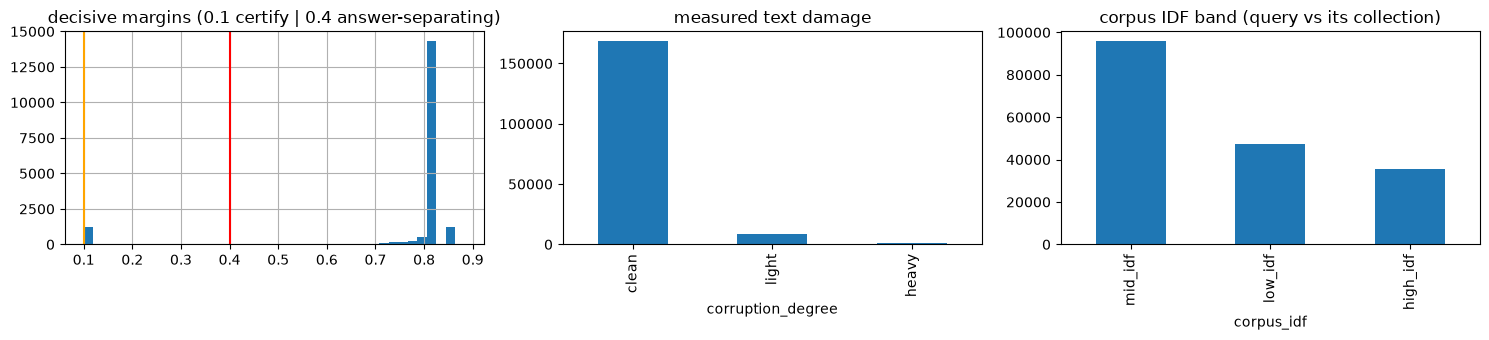

In [7]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
native.loc[native["kind"] == "decisive", "margin"].hist(bins=40, ax=axes[0])
axes[0].axvline(0.1, color="orange"); axes[0].axvline(0.4, color="red")
axes[0].set_title("decisive margins (0.1 certify | 0.4 answer-separating)")
native["corruption_degree"].value_counts().plot.bar(ax=axes[1])
axes[1].set_title("measured text damage")
native["corpus_idf"].value_counts().plot.bar(ax=axes[2])
axes[2].set_title("corpus IDF band (query vs its collection)")
plt.tight_layout(); plt.show()

## 4. v2 → v3, side by side

Same measurement, two generations. v2's 46K rows were labelled with the same
retrieval stack, so the comparison is apples to apples: what changed is HOW
queries were chosen and made. The corpus-relative stats (IDF/OOV/PMI bands)
existed as files in v2 but nothing selected or generated against them; in v3
they are selection axes and the lane-yield measurement behind every
generation quota.

In [8]:
v2 = pool[~pool["native"]]
def profile(frame, name):
    usable = frame[~frame["is_waste"] & (frame["route_class_any"] != "")]
    top_lane = frame["dataset"].value_counts(normalize=True).iloc[0]
    return {
        "rows": len(frame),
        "usable signal": f"{len(usable) / len(frame):.1%}",
        "decisive (margin ≥ 0.1)": int((frame["kind"] == "decisive").sum()),
        "genuine ties (hybrid)": int((frame["kind"] == "genuine_tie").sum()),
        "lanes": frame["dataset"].nunique(),
        "biggest lane's share": f"{top_lane:.1%}",
        "corpus-band coverage": f"{(frame['corpus_idf'] != 'unknown').mean():.1%}",
    }
pd.DataFrame({"v2 era": profile(v2, "v2"), "v3 native": profile(native, "v3")})

,v2 era,v3 native
rows,46142,178768
usable signal,51.9%,45.8%
decisive (margin ≥ 0.1),5268,18217
genuine ties (hybrid),990,446
lanes,42,40
biggest lane's share,18.7%,30.1%
corpus-band coverage,100.0%,100.0%


### The blended share hides a mix effect — decompose by origin

v2's 51.9% usable came from the EASY first draw of the natural well (lanes
where the top answer is nearly guaranteed). v3's natural labelling worked the
hard remainder, and its generated rows are measured against that same hard
material. Like for like, generation out-yields the remaining natural supply.

In [9]:
origin_all = pd.Series("natural (v3-era labelling)", index=native.index)
origin_all[ids.str.startswith("lane-")] = "generated: lane mint"
origin_all[ids.str.startswith("aug-")] = "generated: operator rewrite"
origin_all[ids.str.startswith("syn-")] = "generated: synthetic"
usable_mask = ~native["is_waste"] & (native["route_class_any"] != "")
pd.DataFrame({
    "rows": origin_all.value_counts(),
    "usable signal": usable_mask.groupby(origin_all).mean().round(3),
    "decisive (margin ≥ 0.1)": (native["kind"] == "decisive")
        .groupby(origin_all).mean().round(3),
}).sort_values("usable signal", ascending=False)

,rows,usable signal,decisive (margin ≥ 0.1)
generated: synthetic,197,1.000,0.036
generated: operator rewrite,6716,0.845,0.156
generated: lane mint,99889,0.488,0.120
natural (v3-era labelling),71966,0.379,0.072


### Lane concentration: the pool may be lumpy, the dataset may not

The 20% lane cap binds at the tiers that ship. Pool share is inventory.

In [10]:
top_pool = native["dataset"].value_counts(normalize=True)
top_ds = dataset["dataset"].value_counts(normalize=True)
top_cert = dataset[dataset["certified"]]["dataset"].value_counts(normalize=True)
pd.DataFrame({
    "biggest lane": [top_pool.index[0], top_ds.index[0], top_cert.index[0]],
    "its share": [f"{top_pool.iloc[0]:.1%}", f"{top_ds.iloc[0]:.1%}",
                  f"{top_cert.iloc[0]:.1%}"],
}, index=["pool (inventory)", "dataset (drawn)", "certified (gold)"])

,biggest lane,its share
pool (inventory),scirgen-geo-en,30.1%
dataset (drawn),scirgen-geo-en,20.1%
certified (gold),scirgen-geo-en,18.5%


### The scoreboard in absolute terms

Shares compare mixes; the router trains on rows. And the biggest v3 gain has
no v2 column at all: v2 never produced a balanced artifact — its selection
was flat per-cell quotas with a measured 14x archetype over-representation
and no split guarantee. v3 ships a 45/45/10 dataset with a certified tier,
a frozen eval reserve, and representation bounds that are checked.

In [11]:
v2_usable = v2[~v2["is_waste"] & (v2["route_class_any"] != "")]
v3_usable = native[usable_mask]
def hybrid_supply(frame):
    return int((frame.loc[~frame["is_waste"], "route_class_any"] == "hybrid").sum())
pd.DataFrame({
    "v2 era": [len(v2_usable), int((v2["kind"] == "decisive").sum()),
               hybrid_supply(v2), "none (flat quotas)"],
    "v3 native": [len(v3_usable), int((native["kind"] == "decisive").sum()),
                  hybrid_supply(native),
                  f"{len(dataset):,} rows @ 45/45/10, "
                  f"{int(dataset['certified'].sum()):,} certified"],
}, index=["usable rows (absolute)", "decisive rows (margin ≥ 0.1)",
          "hybrid-class supply", "balanced artifact"])

,v2 era,v3 native
usable rows (absolute),23930,81891
decisive rows (margin ≥ 0.1),5268,18217
hybrid-class supply,5171,21932
balanced artifact,none (flat quotas),"36,711 rows @ 45/45/10, 11,167 certified"


In [12]:
# the same lane, one query from each generation — style side by side
for lane in ("quest", "crumb-set-operation-entity-retrieval"):
    old = v2[v2["dataset"] == lane]
    new = native[(native["dataset"] == lane)
                 & native["query_id"].astype(str).str.startswith("lane-")]
    if old.empty or new.empty:
        continue
    print(f"[{lane}] v2 : {old.sample(1, random_state=3)['query'].iloc[0][:110]}")
    print(f"[{lane}] v3 : {new.sample(1, random_state=3)['query'].iloc[0][:110]}\n")

[quest] v2 : Swans, Dromornithidae or Anseriformes
[quest] v3 : German novel World War II submarine warfare autobiographical

[crumb-set-operation-entity-retrieval] v2 : Films about anti-fascism and sexuality
[crumb-set-operation-entity-retrieval] v3 : science fantasy novels by Lin Carter from the 1970s



## 5. Corruption — what damage does to a query

The corrupt operator takes a real labelled query, damages its surface
(mojibake, paste residue, typos) at the rate the corruption census measured
in real traffic, and the damaged twin is relabelled from scratch. Comparing
each twin to its parent answers the question the axis exists for: does
surface damage change which route wins?

In [12]:
corrupt = generated_pool[generated_pool["operator"] == "corrupt"]
labelled = native.set_index(["dataset", "query_id"])
pairs = []
for row in corrupt.itertuples():
    child = labelled.index.isin([(row.home_lane, row.query_id)])
    parent = labelled.index.isin([(row.parent_dataset, str(row.generated_from))])
    if child.any() and parent.any():
        c = labelled[labelled.index.isin([(row.home_lane, row.query_id)])].iloc[0]
        p = labelled[labelled.index.isin([(row.parent_dataset, str(row.generated_from))])].iloc[0]
        pairs.append({
            "parent_query": p["query"][:70], "corrupted_query": row.query[:70],
            "parent_route": p["route_class_any"], "corrupted_route": c["route_class_any"],
            "parent_margin": round(p["margin"], 3), "corrupted_margin": round(c["margin"], 3),
        })
pairs = pd.DataFrame(pairs)
print(f"corrupted twins with BOTH sides labelled: {len(pairs):,}")
if len(pairs):
    flips = (pairs["parent_route"] != pairs["corrupted_route"]).mean()
    print(f"route changed after corruption: {flips:.1%}")
    display(pairs.sample(min(6, len(pairs)), random_state=5))

corrupted twins with BOTH sides labelled: 6,439
route changed after corruption: 21.1%


,parent_query,corrupted_query,parent_route,corrupted_route,parent_margin,corrupted_margin
5522,Problem: Triangle $ABC$ is a right triangle. If the measure of angle $,Problem: Triangle $ABC$ is a right triangle. If the measure of angle $,,,0.000,0.000
458,Problem: Evaluate: $102^2 - 98^2$,ProblÃ©m: Evaluate: $102^2 - 98^2$,sparse,hybrid,0.005,0.007
5957,Who likes Injera?,Who likes IÃ±jera?,sparse,,0.037,0.000
453,Problem: A 12-slice pizza was made with only pepperoni and mushroom to,Problem: A 12-slice pizza was made with only pepperoni and mushroom to,dense,dense,0.039,0.000
2235,Problem: The hour hand of a clock is 6 inches long and the minute hand,Problem: The hour hand of a clock is 6 inches long and the minute hand,sparse,sparse,0.039,0.039
2976,Finish the following code based on the docstring: import java.util.*;\n,Finish the following code based on the docstring: import java.util.*;\n,dense,dense,0.039,0.060


In [13]:
if len(pairs):
    display(pd.crosstab(pairs["parent_route"], pairs["corrupted_route"],
                        rownames=["clean"], colnames=["corrupted"]))

corrupted,,dense,hybrid,sparse
clean,,,,
,301,7,7,7
dense,271,2409,122,58
hybrid,44,71,374,119
sparse,358,69,226,1996


## 6. The rest of the picture

- **Certified quality tiers**: answer-separating vs rank-preference inside
  the certified set.
- **The three demand ledgers**: what is still owed, and by whom.
- **Trajectory**: the dataset across the folds of 2026-08-20/21.

In [14]:
cert = dataset[dataset["certified"] & (dataset["kind"] == "decisive")]
strict = int((cert["margin"] >= 0.4).sum())
print(f"certified decisive: {len(cert):,} — {strict:,} answer-separating, "
      f"{len(cert) - strict:,} rank-preference")
sheet = pd.read_parquet("../src/data/v3/order_sheet.parquet")
lane_order = pd.read_parquet("../src/data/v3/lane_order.parquet")
mint = lane_order["rows_to_mint"].dropna()
print(f"floor sheet owes    : {sheet['missing'].sum():,.0f} rows "
      f"({len(sheet)} lines)")
print(f"lane rung owes      : {int(mint.sum()):,} mints across {len(mint)} lanes")
ceiling = lane_order.loc["(reachable ceiling)",
                         ["expected_dense", "expected_sparse", "expected_hybrid"]]
print(f"reachable at current yields: {ceiling.astype(int).to_dict()}")

certified decisive: 10,827 — 9,992 answer-separating, 835 rank-preference
floor sheet owes    : 2,752 rows (34 lines)
lane rung owes      : 221,056 mints across 13 lanes
reachable at current yields: {'expected_dense': 61876, 'expected_sparse': 63953, 'expected_hybrid': 46516}


| fold (2026-08) | dataset rows | certified | note |
|---|---|---|---|
| 20 evening — v3-native boundary set | 544 | 60 | day zero of honest v3 |
| 21 early — first labelling folds | 6,760 | 940 | natural well nearly dry |
| 21 night — 100K lane mints folded | **36,711** | **11,167** | hybrid debt reached ZERO |

Remaining path to 200K: dense ~56K and sparse ~64K, carried by the lane
order (needs API credits), cheapened by the tail judge (recovers ties/zeros
instead of minting). Hybrid is funded.